In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ruta del archivo
ruta = r"C:\Users\Victor\Desktop\DIPLOMADO ANALYTICS  DATA\Housing.csv"

# Cargar el archivo CSV
df = pd.read_csv(ruta)

# Mostrar las primeras filas para verificar
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


=== Dimensiones del dataset ===
(545, 13)

=== Tipos de datos ===
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

=== Primeras filas ===
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  

C:\Users\Victor\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


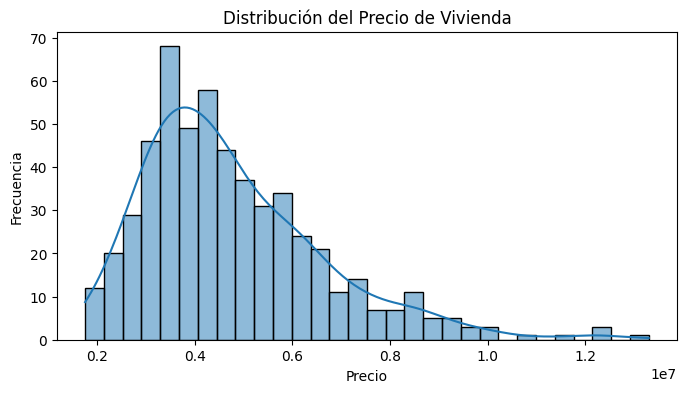

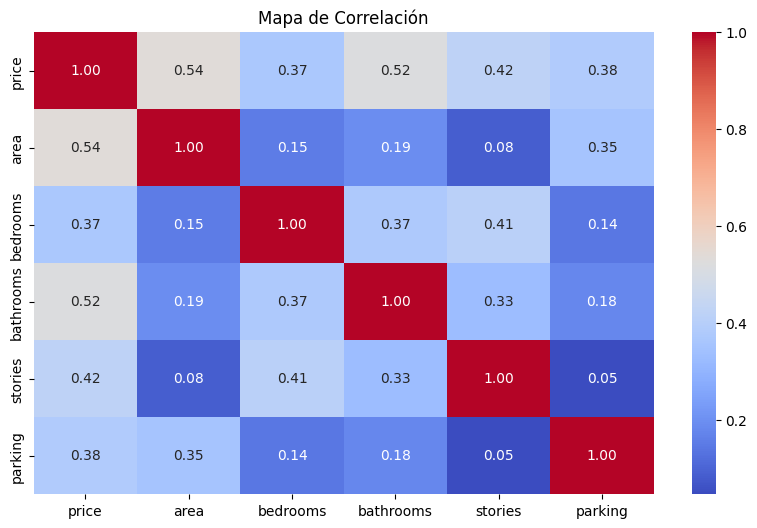

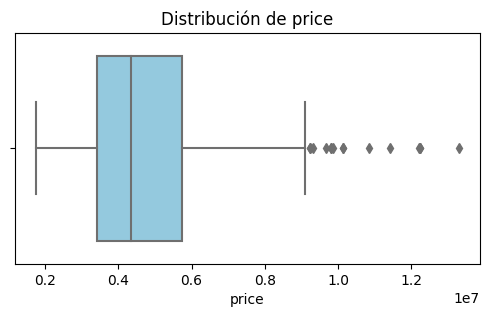

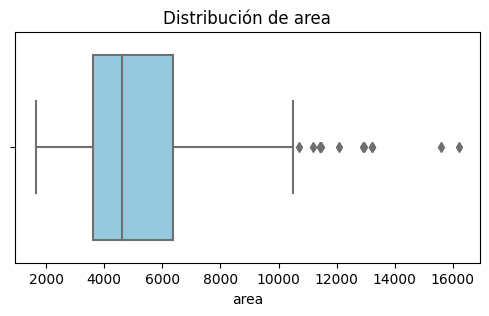

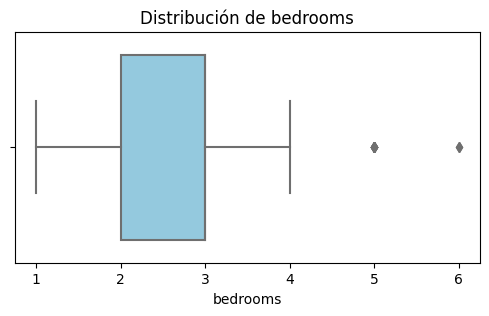

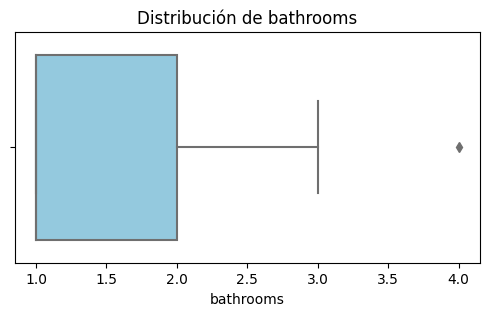

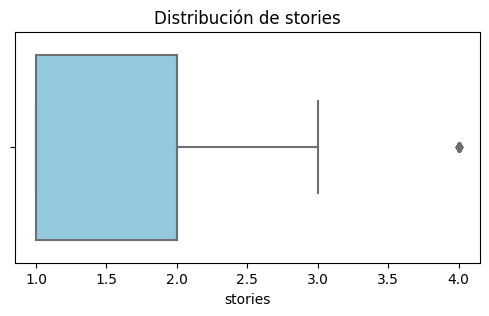

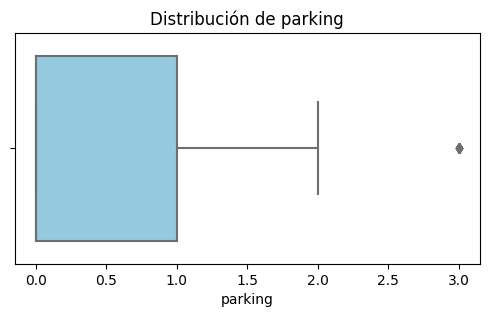

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


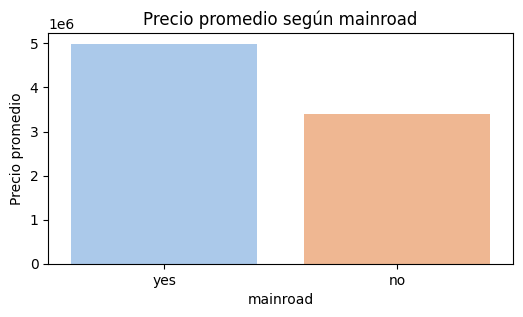

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


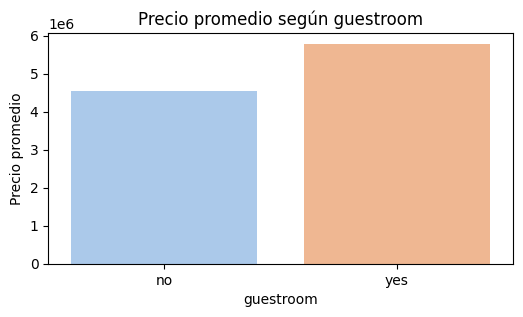

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


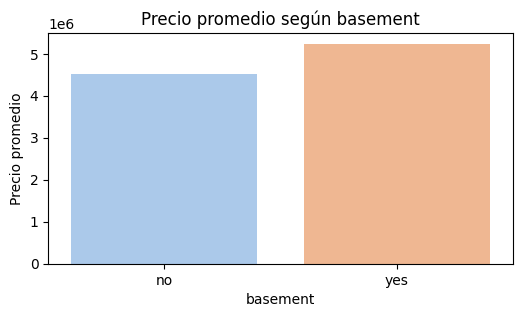

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


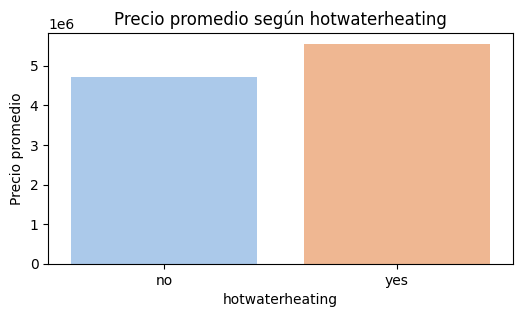

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


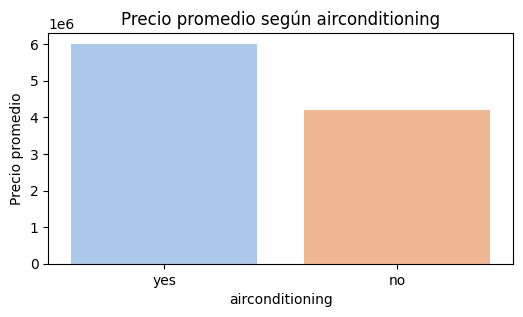

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


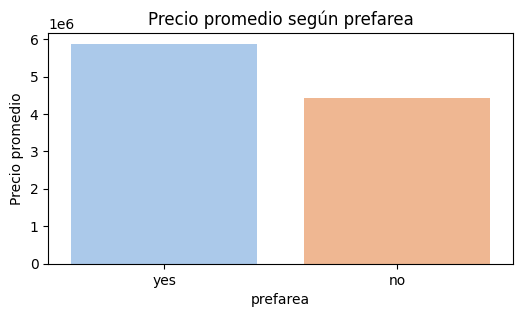

C:\Users\Victor\AppData\Local\Temp\ipykernel_21412\1885676663.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')


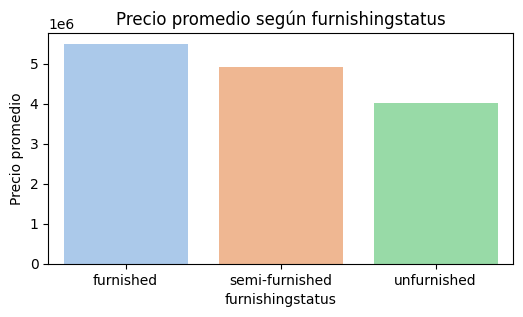

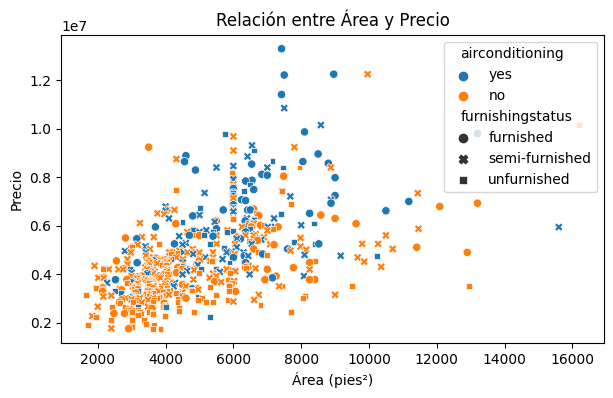


=== Conclusiones iniciales ===

1. El precio se correlaciona fuertemente con el área y el número de pisos.
2. Las casas con aire acondicionado, acceso a carretera principal y zona preferencial tienden a costar más.
3. La mayoría de las variables categóricas parecen tener impacto positivo sobre el precio.
4. Existen algunos valores atípicos en precio y área que conviene revisar.



In [12]:
# =========================================
# 3. Información general
# =========================================
print("=== Dimensiones del dataset ===")
print(df.shape)

print("\n=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Primeras filas ===")
print(df.head())

# =========================================
# 4. Valores nulos y duplicados
# =========================================
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

print("\n=== Registros duplicados ===")
print(df.duplicated().sum())

# =========================================
# 5. Estadísticas descriptivas
# =========================================
print("\n=== Estadísticas numéricas ===")
print(df.describe().T)

# =========================================
# 6. Distribución de la variable objetivo (price)
# =========================================
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribución del Precio de Vivienda')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# =========================================
# 7. Correlaciones entre variables numéricas
# =========================================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación')
plt.show()

# =========================================
# 8. Boxplots para detectar outliers
# =========================================
numericas = ['price','area','bedrooms','bathrooms','stories','parking']
for col in numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.show()

# =========================================
# 9. Análisis categórico vs precio
# =========================================
categoricas = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']

for col in categoricas:
    plt.figure(figsize=(6,3))
    sns.barplot(x=col, y='price', data=df, estimator=np.mean, ci=None, palette='pastel')
    plt.title(f'Precio promedio según {col}')
    plt.ylabel('Precio promedio')
    plt.show()

# =========================================
# 10. Relación entre área y precio
# =========================================
plt.figure(figsize=(7,4))
sns.scatterplot(x='area', y='price', data=df, hue='airconditioning', style='furnishingstatus')
plt.title('Relación entre Área y Precio')
plt.xlabel('Área (pies²)')
plt.ylabel('Precio')
plt.show()

# =========================================
# 11. Conclusión rápida (en consola)
# =========================================
print("\n=== Conclusiones iniciales ===")
print("""
1. El precio se correlaciona fuertemente con el área y el número de pisos.
2. Las casas con aire acondicionado, acceso a carretera principal y zona preferencial tienden a costar más.
3. La mayoría de las variables categóricas parecen tener impacto positivo sobre el precio.
4. Existen algunos valores atípicos en precio y área que conviene revisar.
""")